# Energy Demand Analysis

## Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## Data Loading

In [2]:
df=pd.read_csv("electricity_demand.csv")
df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


## Data Understanding

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Columns: 300 entries, utc_timestamp to UA_load_forecast_entsoe_transparency
dtypes: float64(298), str(2)
memory usage: 115.4 MB


In [4]:
df.describe()


,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
count,50400.000000,50400.000000,32845.000000,50339.000000,50352.000000,50400.000000,50376.000000,50385.000000,46466.000000,46466.000000,...,50340.000000,50398.000000,50391.000000,50379.000000,5.037300e+04,50398.000000,50010.000000,9679.000000,25635.000000,25413.000000
mean,7070.148631,7039.848552,33.934663,135.280121,729.653261,9808.383929,9759.323567,393.402158,779.920474,433.482914,...,1462.742614,1465.434762,31.886199,0.546785,3.336826e+03,3288.454423,60.563224,0.684807,17006.680807,17290.802306
std,1400.263167,1355.382837,14.944863,198.955378,692.002497,1393.548610,1380.214097,621.803385,665.931016,400.823333,...,262.562188,260.132266,47.972831,0.726016,9.678832e+03,457.612965,91.983827,2.531283,2776.794985,2741.479932
min,664.000000,3739.000000,-76.000000,0.000000,0.000000,6245.000000,6522.000000,0.000000,1.090000,0.000000,...,24.240000,753.000000,0.000000,0.000000,1.830000e+03,2040.000000,0.000000,0.000000,10905.000000,11450.000000
25%,5941.000000,5941.000000,25.000000,0.000000,162.000000,8706.000000,8671.000000,0.000000,245.532500,103.652500,...,1252.360000,1253.000000,0.040000,0.000000,2.942000e+03,2940.000000,0.000000,0.000000,15048.000000,15420.000000
50%,7032.000000,7018.000000,33.000000,18.000000,493.000000,9809.000000,9757.000000,10.670000,571.515000,317.345000,...,1463.970000,1474.000000,1.850000,0.270000,3.295000e+03,3300.000000,2.900000,0.300000,16678.000000,16905.000000
75%,8079.000000,7986.000000,42.000000,224.000000,1141.000000,10852.000000,10813.250000,596.400000,1171.482500,650.000000,...,1658.702500,1662.000000,52.530000,0.790000,3.600000e+03,3600.000000,97.900000,0.800000,18862.000000,19173.000000
max,10803.000000,11608.000000,187.000000,1166.000000,2969.000000,13670.000000,13454.000000,3281.400000,3252.680000,1944.160000,...,2402.250000,2206.000000,717.820000,4.670000,2.170811e+06,4520.000000,387.200000,36.500000,24684.000000,24739.000000


In [5]:
df.columns


Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       ...
       'SI_load_actual_entsoe_transparency',
       'SI_load_forecast_entsoe_transparency', 'SI_solar_generation_actual',
       'SI_wind_onshore_generation_actual',
       'SK_load_actual_entsoe_transparency',
       'SK_load_forecast_entsoe_transparency', 'SK_solar_generation_actual',
       'SK_wind_onshore_generation_actual',
       'UA_load_actual_entsoe_transparency',
       'UA_load_forecast_entsoe_transparency'],
      dtype='str', length=300)

## Feature Selection

In [6]:
selected_columns = [
    'utc_timestamp',
    'AT_load_actual_entsoe_transparency',
    'AT_load_forecast_entsoe_transparency',
    'AT_price_day_ahead',
    'AT_solar_generation_actual',
    'AT_wind_onshore_generation_actual'
]
df_selected=df[selected_columns]
df_selected.head()

,utc_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual
0,2014-12-31T23:00:00Z,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,5946.0,6701.0,35.0,NaN,69.0
2,2015-01-01T01:00:00Z,5726.0,6593.0,45.0,NaN,64.0
3,2015-01-01T02:00:00Z,5347.0,6482.0,41.0,NaN,65.0
4,2015-01-01T03:00:00Z,5249.0,6454.0,38.0,NaN,64.0


In [12]:
df_selected.isnull().sum()


utc_timestamp                           0
AT_load_actual_entsoe_transparency      1
AT_load_forecast_entsoe_transparency    1
AT_solar_generation_actual              8
AT_wind_onshore_generation_actual       1
dtype: int64

## Data Cleaning

In [11]:
df_selected=df_selected.drop(columns=['AT_price_day_ahead'])

In [8]:
df_selected.isnull().sum()


utc_timestamp                               0
AT_load_actual_entsoe_transparency          1
AT_load_forecast_entsoe_transparency        1
AT_price_day_ahead                      17556
AT_solar_generation_actual                 62
AT_wind_onshore_generation_actual          49
dtype: int64

In [10]:
df_selected=df_selected.ffill()

In [11]:
df_selected.isnull().sum()

utc_timestamp                           0
AT_load_actual_entsoe_transparency      1
AT_load_forecast_entsoe_transparency    1
AT_solar_generation_actual              8
AT_wind_onshore_generation_actual       1
dtype: int64

In [14]:
df_selected=df_selected.bfill()

In [15]:
df_selected.isnull().sum()

utc_timestamp                           0
AT_load_actual_entsoe_transparency      0
AT_load_forecast_entsoe_transparency    0
AT_solar_generation_actual              0
AT_wind_onshore_generation_actual       0
dtype: int64

In [18]:
#df_selected=df_selected.corr(numeric_only=True)


## Correlation Analysis

In [12]:
df_selected.corr(numeric_only=True)

,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_solar_generation_actual,AT_wind_onshore_generation_actual
AT_load_actual_entsoe_transparency,1.000000,0.939631,0.212319,0.063814
AT_load_forecast_entsoe_transparency,0.939631,1.000000,0.200912,0.055315
AT_solar_generation_actual,0.212319,0.200912,1.000000,-0.097239
AT_wind_onshore_generation_actual,0.063814,0.055315,-0.097239,1.000000


## Exploratory Data Analysis

### Wind vs Load

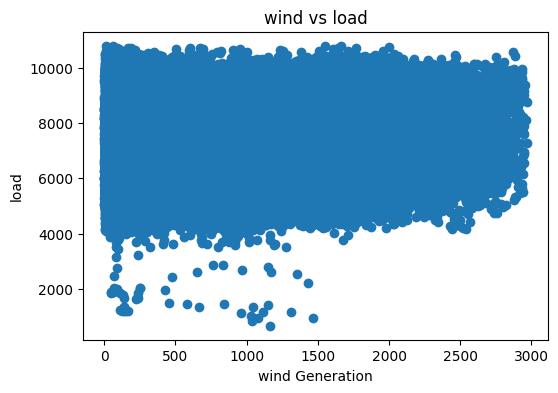

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
plt.scatter(df_selected['AT_wind_onshore_generation_actual'],
                       df_selected['AT_load_actual_entsoe_transparency'])
plt.xlabel('wind Generation')
plt.ylabel('load')
plt.title('wind vs load')
plt.show()

The scatter plot shows no strong relationship between wind generation and electricity demand.


### Solar vs Load

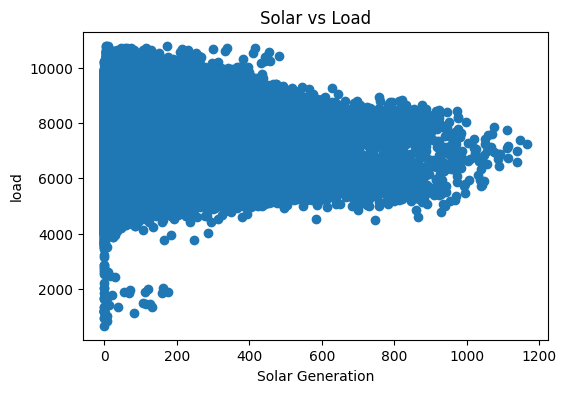

In [15]:
plt.figure(figsize=(6,4))
plt.scatter( 
    df_selected['AT_solar_generation_actual'],
    df_selected['AT_load_actual_entsoe_transparency']
)
plt.xlabel('Solar Generation')
plt.ylabel('load')
plt.title('Solar vs Load')
plt.show()

The scatter plot suggests a weak   negative relationship between solar generation and electricity demand.

## Coorelation Analysis

### Coorelation Heatmap

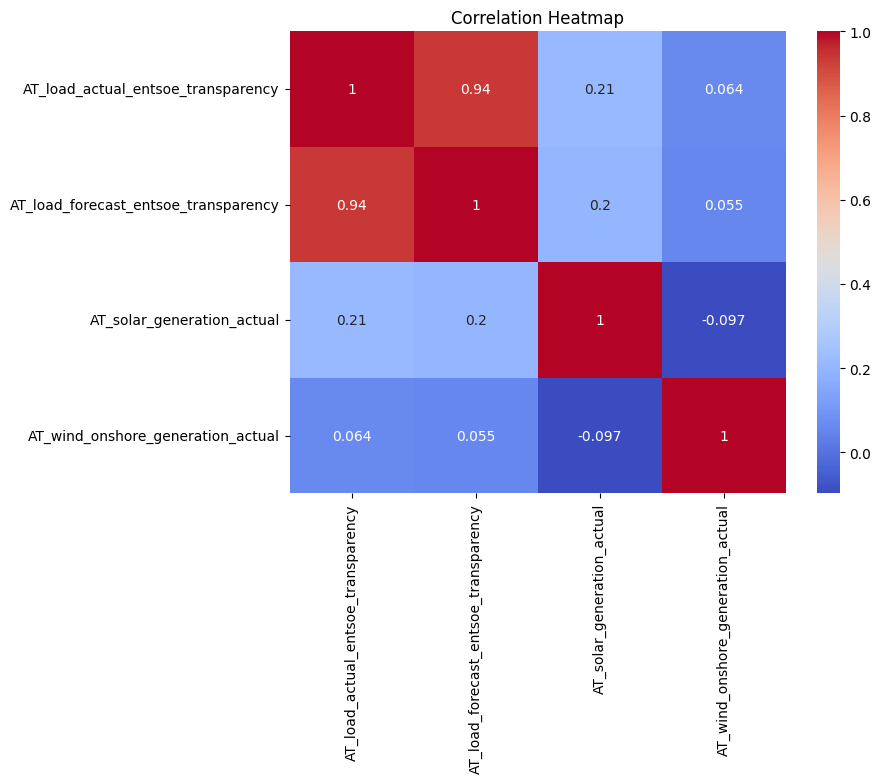

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df_selected.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title ('Correlation Heatmap')
plt.show()

The heatmap shows a strong positive correlation between actual load and forecasted load , indicating accurate predictions. 
Solar and Wind generation show weak relationships with electricity demand.

## Key Insights

- There is no strong relationship between wind generation and electricity demand.
- Solar generation shows a weak negative relationship with demand.
- Forecasted load is highly correlated with actual load, indicating accurate predictions.
